# Jax's `grad`

## Lesson Goals:

By the end of this lesson, you will understand the main `grad`-related functions that `jax` exposes, and when to use them. By 

**Note**: Autodiff and the various optimizations one can implement are a very deep area of study. Our aim here is to give you a high-level overview and teach you enough to be dangerous

## Core Concepts:

- `grad` and `value_and_grad`
- `jacfwd`
- `jacrev`


## Additional Reading:

Here is a bit more information, with links to sources that we've vetted

- [Bonus - JVP and VJP](./bonus_autodiff_jvp_vjp.ipynb)


## Concepts In action:

TODO!

In [13]:
import jax
import jax.numpy as jnp
from jax import vmap
from jax import grad, value_and_grad
import matplotlib.pyplot as plt

# Vanilla Gradient: `jax.grad`

- `jax.grad` is the simplest form of taking a gradient in jax, and is what you will probably use 90% of the time.
- with `jax.grad` you can take the gradient arbitrarily many times. Let's explore this
- it accepts a function and returns a new function! 

## `grad` signature

Assume `CT a` refers to the "space" that the gradients of `a` live in$^\text{Note}$Say the `grad` function has the following signature:

`grad :: (a -> b) -> (a -> (CT a))`

as a function that accepts a function and returns a new function that accepts a vector, along which to take the gradient, and returns the gradient.

$^\text{Note}$ see [Bonus - JVP and VJP](./bonus_autodiff_jvp_vjp.ipynb) if you're really interested, but it's not necessary. 

---

Let's now consider a simple example:


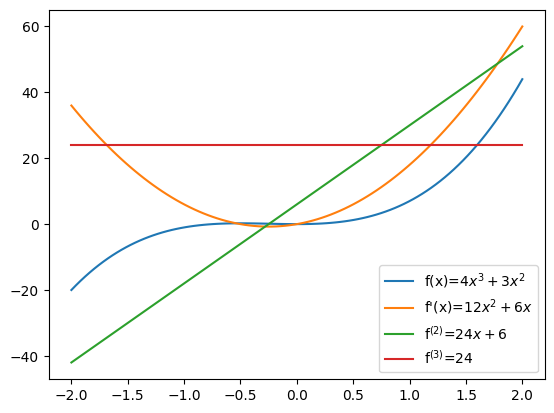

In [28]:
x = jnp.linspace(-2, 2, 100)

def arbitrary_gradients():
    """
    TODO: @Ian remove the solutions here
    TODO:
        take the gradient of `fx` up to the third degree! You will find `vmap` useful
    """
    fx = lambda x: 4*x**3 + 3*x**2
    

    d1_dx = vmap(lambda x: grad(fx)(x))
    d2_dx = vmap(lambda x: grad(grad(fx))(x))
    d3_dx = vmap(lambda x: grad(grad(grad(fx)))(x))
    
    plt.plot(x, fx(x), label="f(x)=$4x^3 + 3x^2$")
    plt.plot(x, d1_dx(x), label="f'(x)=$12x^2 + 6x$")
    plt.plot(x, d2_dx(x), label="f$^{(2)}$=$24x + 6$")
    plt.plot(x, d3_dx(x), label="f$^{(3)}$=24")
    plt.legend()
    plt.show()

arbitrary_gradients()

## `value_and_grad` signature

The gradient was useful, but other times we want to get the value of the function evaluation and the gradient simultaneously, which is where `value_and_grad` comes in. `value_and_grad` has the signature of:

`value_and_grad :: (a -> b) -> (a -> (b, CT a))`

i.e. it is a function that accepts a function and returns a new function (that returns a tuple):

- our `b`, the result of the function evaluation
- our `CT a` is the gradient of the input, in the "gradient" space.

---

Let's now consider a simple example (note: the additional arguments are present in both `grad` and `value_and_grad`)

In [38]:

W = jnp.asarray([jnp.pi - 0.55, 2 * jnp.pi - 0.55])
b = jnp.asarray([0.5])

def simple_loss(W, b):
    W_prime = jnp.asarray([jnp.pi, 2 * jnp.pi])
    target = jnp.cos(W_prime)
    diff = target - (jnp.cos(W) + b)
    return jnp.sum(jnp.sqrt(diff ** 2))

# Gradient with respect to the 0-th argument of `simple_loss`.
# NOTE: if argnums is not passed in, jax will default to the derivative wrt. the first argument 
# of the `simple_loss` function
loss_val, W_grad = value_and_grad(simple_loss, argnums=0)(W, b)
print(f'{W_grad=}')
print(f'{loss_val=}')
print("#" * 10)

# Unsurprisingly, we can also take the gradient with respect to both arguments at once
loss_val, (W_grad, b_grad) = value_and_grad(simple_loss, (0, 1))(W, b)
print(f'{W_grad=}')
print(f'{b_grad=}')
print(f'{loss_val=}')

W_grad=Array([-0.5226873 ,  0.52268726], dtype=float32)
loss_val=Array(1., dtype=float32)
##########
W_grad=Array([-0.5226873 ,  0.52268726], dtype=float32)
b_grad=Array([2.], dtype=float32)
loss_val=Array(1., dtype=float32)


In [39]:
loss_val, W_grad = value_and_grad(simple_loss, argnums=0)(W + W_grad, b + b_grad)
print(loss_val)

5.521862


## Getting the `grad` of a structure

- `grad` doesn't require that we pass in jax arrays - we can theoretically pass in any container type, so long as we "register" it with `jax` (more on this in the 

# AutoDiff Primer

- All AD frameworks are implemented as either one of two "modes": forward-mode or reverse-mode. Typically you won't have to worry about these details.

Jax has two functions that expose this "lower-level" detail: 

- [jacrev](https://docs.jax.dev/en/latest/_autosummary/jax.jacrev.html), which finds the jacobian of the input function, evaluated row-by-row using reverse-mode AD

- [jacfwd](https://docs.jax.dev/en/latest/_autosummary/jax.jacfwd.html), which finds the jacobian of the input function, evaluated column-by-column using forward-mode AD.

In [ ]:
## jacrev

In [ ]:
## jacfwd